### 2448509 Ashwin Rajan 
### LAB 1

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Global names to keep output consistent
ARM_NAMES = ['Top Banner', 'Sidebar', 'Footer', 'Pop-up']

In [10]:
class EpsilonGreedyBandit:
    def __init__(self, n_arms, epsilon=0.1, arm_names=None):
        """
        Initialize the Multi-Armed Bandit

        Parameters:
        - n_arms: Number of arms/ad slots
        - epsilon: Exploration rate (0.1 = 10% exploration)
        - arm_names: Optional list of names for arms
        """
        self.n_arms = int(n_arms)
        self.epsilon = float(epsilon)
        self.counts = np.zeros(n_arms, dtype=int)   # # of pulls per arm
        self.values = np.zeros(n_arms, dtype=float) # estimated CTR per arm
        self.arm_names = arm_names if arm_names is not None else [f'Arm {i}' for i in range(n_arms)]

    def select_arm(self):
        """
        Select an arm using epsilon-greedy strategy
        """
        if random.random() < self.epsilon:
            # Exploration: choose random arm
            return random.randint(0, self.n_arms - 1)
        else:
            # Exploitation: choose arm with highest estimated CTR
            # If there are ties, np.argmax returns the first; that's fine for this lab
            return int(np.argmax(self.values))

    def update(self, chosen_arm, reward):
        """
        Update the estimated CTR for the chosen arm

        Parameters:
        - chosen_arm: The arm that was selected
        - reward: 1 if clicked, 0 if not clicked
        """
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]

        # Incremental average: new_mean = old_mean + (reward - old_mean) / n
        current_value = self.values[chosen_arm]
        self.values[chosen_arm] = current_value + (reward - current_value) / n

    def get_stats(self):
        """Return current statistics"""
        return {
            'counts': self.counts.copy(),
            'values': self.values.copy(),
            'total_impressions': int(np.sum(self.counts)),
            'total_clicks': float(np.sum(self.values * self.counts))
        }


In [11]:
def simulate_click(ad_slot, true_ctrs):
    """
    Simulate whether a user clicks on an ad in the given slot

    Parameters:
    - ad_slot: The ad slot being shown
    - true_ctrs: True CTRs for each ad slot

    Returns:
    - 1 if clicked, 0 otherwise
    """
    return 1 if random.random() < true_ctrs[ad_slot] else 0

# --- Stationary environment (fixed, unknown in reality) ---
# Order: [Top Banner, Sidebar, Footer, Pop-up]
true_ctrs_start = [0.08, 0.12, 0.05, 0.15]

# --- Optional Non-stationary toggle ---
SIM_NON_STATIONARY = True       # set to False to keep fixed CTRs
CHANGE_POINT = 500              # after this many impressions, pop-up changes
POPUP_NEW_CTR = 0.06            # example: pop-up becomes less effective (0.15 -> 0.06)

def get_true_ctrs_at_t(t):
    """
    Return the 'true' CTRs at impression t (0-indexed).
    If SIM_NON_STATIONARY=False, this just returns the initial vector.
    """
    if not SIM_NON_STATIONARY:
        return true_ctrs_start
    # non-stationary: only pop-up (index 3) changes after CHANGE_POINT
    if t >= CHANGE_POINT:
        return [true_ctrs_start[0], true_ctrs_start[1], true_ctrs_start[2], POPUP_NEW_CTR]
    else:
        return true_ctrs_start


In [12]:
# Hyperparameters
n_impressions = 1000
epsilon = 0.10

# Initialize the bandit
bandit = EpsilonGreedyBandit(n_arms=4, epsilon=epsilon, arm_names=ARM_NAMES)

# Tracking for analysis and plots
results = {
    'clicks_per_arm': [0, 0, 0, 0],
    'impressions_per_arm': [0, 0, 0, 0],
    'ctr_history': [],        # actual CTR observed so far per arm at checkpoints
    'arm_selections': [],     # cumulative impressions per arm at checkpoints
    'cum_clicks_over_time': [],  # running total clicks
    'regret_over_time': [],      # per-step dynamic regret vs best current arm
}

print("Starting Multi-Armed Bandit Simulation for Ad Slots")
print("=" * 50)
print(f"Initial True CTRs: {dict(zip(bandit.arm_names, true_ctrs_start))}")
print(f"Epsilon (explore rate): {epsilon}")
print(f"Non-stationary: {SIM_NON_STATIONARY} (change after t={CHANGE_POINT})\n")


Starting Multi-Armed Bandit Simulation for Ad Slots
Initial True CTRs: {'Top Banner': 0.08, 'Sidebar': 0.12, 'Footer': 0.05, 'Pop-up': 0.15}
Epsilon (explore rate): 0.1
Non-stationary: True (change after t=500)



In [13]:
total_clicks = 0
cum_regret = 0.0

for t in range(n_impressions):
    # Get true CTRs at this time t (handles stationary / non-stationary)
    true_ctrs_t = get_true_ctrs_at_t(t)

    # Choose arm
    chosen_arm = bandit.select_arm()

    # Simulate reward
    click = simulate_click(chosen_arm, true_ctrs_t)

    # Update bandit
    bandit.update(chosen_arm, click)

    # Update trackers
    results['impressions_per_arm'][chosen_arm] += 1
    if click == 1:
        results['clicks_per_arm'][chosen_arm] += 1
        total_clicks += 1

    # Dynamic regret vs. an oracle that would pick the best CURRENT arm at time t
    best_ctr_now = max(true_ctrs_t)
    regret_t = best_ctr_now - (true_ctrs_t[chosen_arm])
    cum_regret += regret_t
    results['regret_over_time'].append(cum_regret)
    results['cum_clicks_over_time'].append(total_clicks)

    # Store history every 100 impressions (and the very last one)
    if (t % 100 == 0) or (t == n_impressions - 1):
        current_actual_ctrs = [
            results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
            for i in range(4)
        ]
        results['ctr_history'].append(current_actual_ctrs.copy())
        results['arm_selections'].append(results['impressions_per_arm'].copy())


In [14]:
print("Simulation Complete!")
print("=" * 50)
print("\nFinal Results:")
print("-" * 30)

stats = bandit.get_stats()
for i in range(4):
    actual_ctr = results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
    true_ctr_last = get_true_ctrs_at_t(n_impressions - 1)[i]
    print(f"{bandit.arm_names[i]:<12}: "
          f"Impressions: {results['impressions_per_arm'][i]:<4} | "
          f"Clicks: {results['clicks_per_arm'][i]:<3} | "
          f"Estimated CTR: {bandit.values[i]:.3f} | "
          f"Actual CTR: {actual_ctr:.3f} | "
          f"True CTR (at end): {true_ctr_last:.3f}")

overall_ctr = total_clicks / n_impressions
print(f"\nTotal Impressions: {n_impressions}")
print(f"Total Clicks: {total_clicks}")
print(f"Overall CTR: {overall_ctr:.3f}")


Simulation Complete!

Final Results:
------------------------------
Top Banner  : Impressions: 108  | Clicks: 8   | Estimated CTR: 0.074 | Actual CTR: 0.074 | True CTR (at end): 0.080
Sidebar     : Impressions: 85   | Clicks: 8   | Estimated CTR: 0.094 | Actual CTR: 0.094 | True CTR (at end): 0.120
Footer      : Impressions: 33   | Clicks: 2   | Estimated CTR: 0.061 | Actual CTR: 0.061 | True CTR (at end): 0.050
Pop-up      : Impressions: 774  | Clicks: 60  | Estimated CTR: 0.078 | Actual CTR: 0.078 | True CTR (at end): 0.060

Total Impressions: 1000
Total Clicks: 78
Overall CTR: 0.078


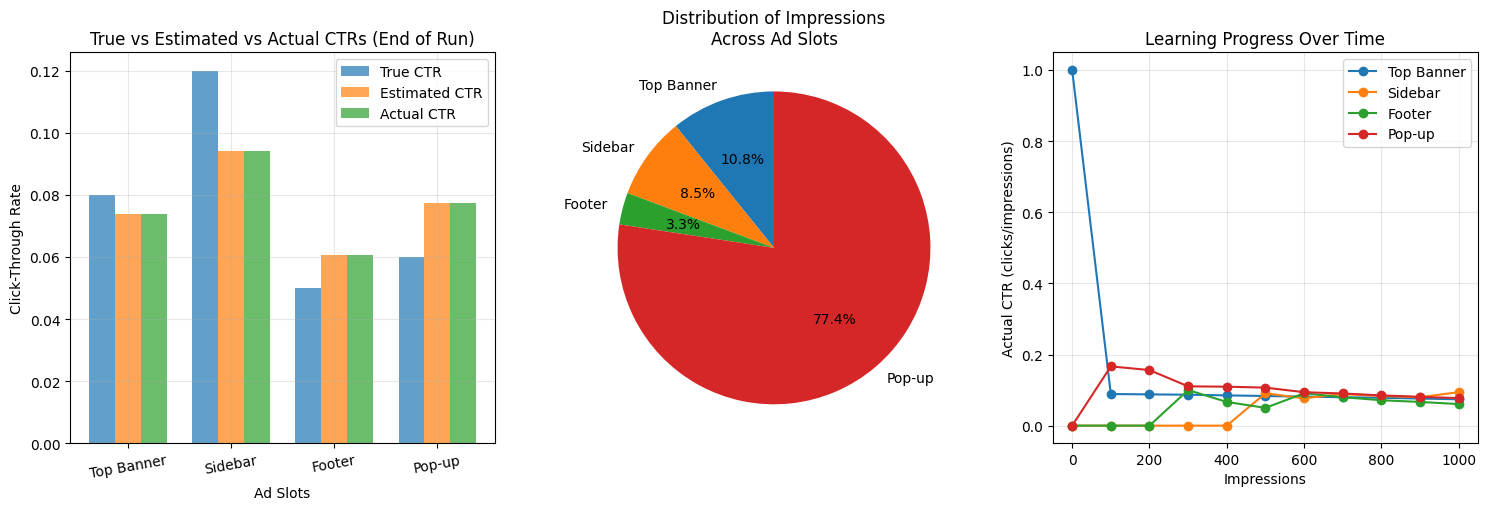

In [15]:
plt.figure(figsize=(15, 5))

# Plot 1: Estimated vs True vs Actual CTRs (end-of-run snapshot)
plt.subplot(1, 3, 1)
x_pos = np.arange(len(bandit.arm_names))
width = 0.25

true_ctrs_end = get_true_ctrs_at_t(n_impressions - 1)
estimated_ctrs = bandit.values
actual_ctrs = [
    results['clicks_per_arm'][i] / max(1, results['impressions_per_arm'][i])
    for i in range(4)
]

plt.bar(x_pos - width, true_ctrs_end, width, label='True CTR', alpha=0.7)
plt.bar(x_pos, estimated_ctrs, width, label='Estimated CTR', alpha=0.7)
plt.bar(x_pos + width, actual_ctrs, width, label='Actual CTR', alpha=0.7)

plt.xlabel('Ad Slots')
plt.ylabel('Click-Through Rate')
plt.title('True vs Estimated vs Actual CTRs (End of Run)')
plt.xticks(x_pos, bandit.arm_names, rotation=10)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Impressions Distribution (pie)
plt.subplot(1, 3, 2)
plt.pie(results['impressions_per_arm'], labels=bandit.arm_names, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Impressions\nAcross Ad Slots')

# Plot 3: Learning Progress of Actual CTRs (checkpoints)
plt.subplot(1, 3, 3)
history_points = len(results['ctr_history'])
# avoid div-by-zero if someone changes checkpoints
denom = max(1, history_points - 1)
x_vals = [i * (n_impressions // denom) for i in range(history_points)]

for i in range(4):
    ctr_progress = [results['ctr_history'][j][i] for j in range(history_points)]
    plt.plot(x_vals, ctr_progress, label=bandit.arm_names[i], marker='o')

plt.xlabel('Impressions')
plt.ylabel('Actual CTR (clicks/impressions)')
plt.title('Learning Progress Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


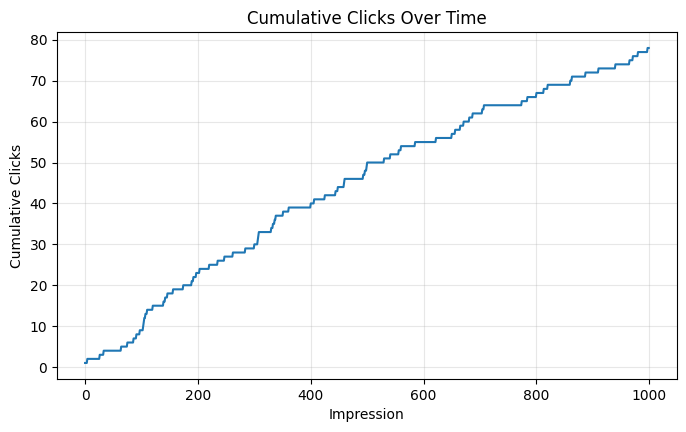

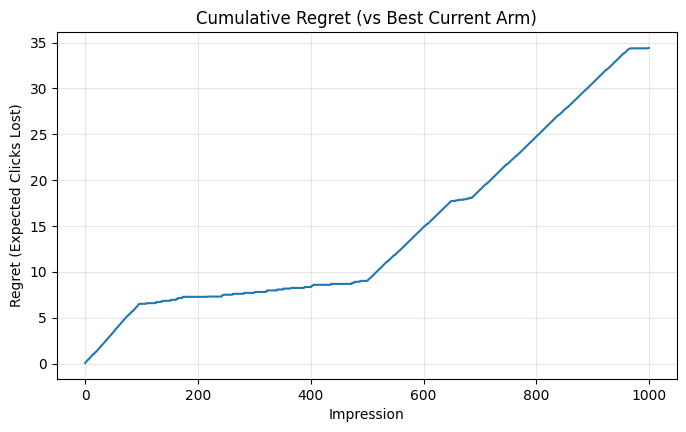

In [16]:
# Cumulative clicks over time
plt.figure(figsize=(8, 4.5))
plt.plot(results['cum_clicks_over_time'])
plt.title('Cumulative Clicks Over Time')
plt.xlabel('Impression')
plt.ylabel('Cumulative Clicks')
plt.grid(True, alpha=0.3)
plt.show()

# Cumulative dynamic regret vs best-current arm
plt.figure(figsize=(8, 4.5))
plt.plot(results['regret_over_time'])
plt.title('Cumulative Regret (vs Best Current Arm)')
plt.xlabel('Impression')
plt.ylabel('Regret (Expected Clicks Lost)')
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
print("\nPerformance Analysis:")
print("-" * 30)

# Best *constant* arm based on initial true CTRs (typical classroom metric)
best_arm_constant = int(np.argmax(true_ctrs_start))
optimal_clicks_constant = n_impressions * true_ctrs_start[best_arm_constant]
actual_clicks = sum(results['clicks_per_arm'])
regret_constant = optimal_clicks_constant - actual_clicks
efficiency_constant = (actual_clicks / optimal_clicks_constant) * 100

print(f"Best constant ad slot (by initial true CTRs): {bandit.arm_names[best_arm_constant]} "
      f"(CTR: {true_ctrs_start[best_arm_constant]:.3f})")
print(f"Optimal strategy clicks (constant oracle): {optimal_clicks_constant:.1f}")
print(f"Actual clicks: {actual_clicks}")
print(f"Regret (lost clicks vs constant oracle): {regret_constant:.1f}")
print(f"Efficiency: {efficiency_constant:.1f}%")

# Also report dynamic-regret final value (vs best CURRENT arm each step)
print(f"Dynamic-regret (vs best current arm) at end: {results['regret_over_time'][-1]:.1f}")



Performance Analysis:
------------------------------
Best constant ad slot (by initial true CTRs): Pop-up (CTR: 0.150)
Optimal strategy clicks (constant oracle): 150.0
Actual clicks: 78
Regret (lost clicks vs constant oracle): 72.0
Efficiency: 52.0%
Dynamic-regret (vs best current arm) at end: 34.4
